# EDA: 전국_소방서_좌표.csv
이 노트북에서는 `data/processed/전국_소방서_좌표.csv` 파일을 중심으로 주요 분포, 결측값, 지역별 소방서 수를 분석합니다.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

data_path = Path('data') / 'processed' / '전국_소방서_좌표.csv'
df = pd.read_csv(data_path, encoding='utf-8-sig')
df.columns = ['소방서 및 안전센터명', '위도', '경도', '시도', '시군구', '상세주소', '상위 본부명']
for col in ['시도', '시군구', '상위 본부명']:
    df[col] = df[col].astype('string')
df.head()


FileNotFoundError: [Errno 2] No such file or directory: 'data\\processed\\전국_소방서_좌표.csv'

In [4]:
print('shape:', df.shape)
print('columns:', df.columns.tolist())
print('missing values:')
display(df.isna().sum())
print('기본 통계 요약:')
display(df.describe(include='all').transpose())


NameError: name 'df' is not defined

In [ ]:
print('시도별 소방서 수 (상위 20):')
display(df['시도'].value_counts().head(20))
print('시군구별 소방서 수 (상위 20):')
display(df['시군구'].value_counts().head(20))
print('상위 본부명별 소방서 수 (상위 20):')
display(df['상위 본부명'].value_counts().head(20))


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df.plot.scatter(x='경도', y='위도', alpha=0.6, s=20, ax=axes[0])
axes[0].set_title('전국 소방서 위치 분포')
axes[0].set_xlabel('경도')
axes[0].set_ylabel('위도')
top_region = df['시도'].value_counts().head(15)
axes[1].barh(top_region.index, top_region.values, color='tab:blue')
axes[1].set_title('시도별 소방서 수 (Top 15)')
axes[1].set_xlabel('소방서 수')
axes[1].set_ylabel('시도')
plt.tight_layout()
plt.show()


위도 / 경도 분포


NameError: name 'df' is not defined

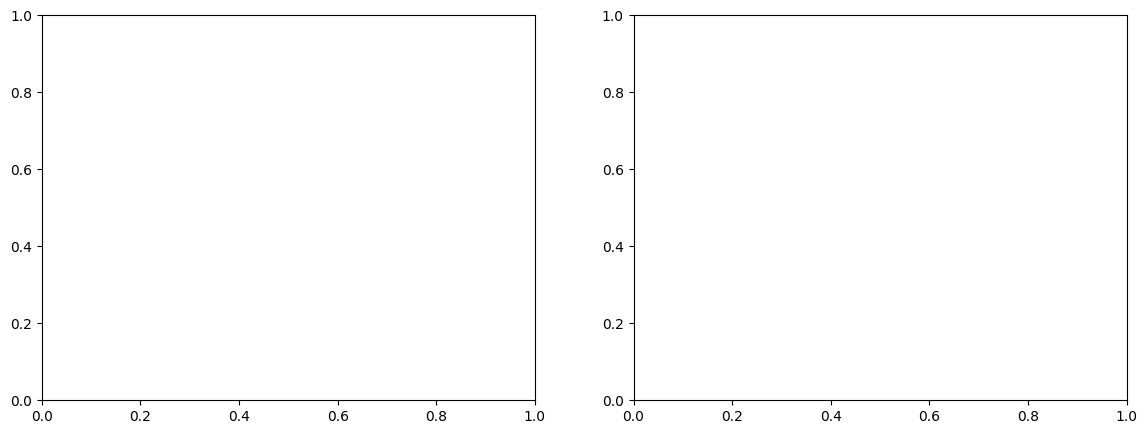

In [2]:
print('위도 / 경도 분포')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['위도'].dropna(), bins=25, color='tab:blue', alpha=0.75)
axes[0].set_title('위도 분포')
axes[0].set_xlabel('위도')
axes[0].set_ylabel('빈도')
axes[1].hist(df['경도'].dropna(), bins=25, color='tab:green', alpha=0.75)
axes[1].set_title('경도 분포')
axes[1].set_xlabel('경도')
axes[1].set_ylabel('빈도')
plt.tight_layout()
plt.show()
